# 02 - EDA, WOE & IV

- Data profiling: missing value, phan bo bien, outlier
- Data cleaning: xu ly missing/outlier, encode categorical
- Univariate + bivariate voi loan_status
- Tinh WOE/IV cho tung bien ung vien

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from src.paths import DATA_RAW, DATA_INTERIM, DATA_PROCESSED, MODELS, REPORTS_FIGURES

## Data profiling

In [2]:
import numpy as np

accepted = pd.read_parquet(DATA_INTERIM / 'accepted_vintage_2015_2017.parquet')

# grade/sub_grade/int_rate bi loai khoi feature du bao: day la KET QUA tu underwriting
# noi bo cua LC (LC tu cham grade roi gan int_rate theo grade), khong phai dac diem tho
# cua khach hang. Dua vao lam predictor se khien model chu yeu hoc lai grade cua LC thay
# vi danh gia rui ro doc lap. int_rate duoc giu rieng, chi dung tinh Expected Net Return
# o notebook 05. Danh sach day du: src/data/filter_vintage.py:LENDER_DECISION_COLUMNS.
#
# Sprint 2: mo rong tu 17 len 81 bien, dong bo voi candidate set cua notebook 03 - de bang
# xep hang RQ1 (IV toan bo vintage) phan anh dung toan bo bien ung vien dang xet cho model,
# khong chi 17 bien cu cua Sprint 1.
CANDIDATE_FEATURES = [
    'loan_amnt', 'term', 'emp_length', 'home_ownership', 'annual_inc', 'purpose',
    'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'addr_state',
    'verification_status', 'application_type', 'disbursement_method',
    'acc_now_delinq', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
    'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'delinq_amnt',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mo_sin_old_il_acct',
    'mort_acc', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'mths_since_rcnt_il',
    'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl',
    'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats',
    'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
    'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
    'tot_coll_amt', 'tot_cur_bal', 'tot_hi_cred_lim', 'total_bal_ex_mort',
    'total_bc_limit', 'total_il_high_credit_limit', 'total_rev_hi_lim',
    'il_util', 'all_util', 'total_bal_il', 'open_il_12m', 'open_il_24m', 'open_act_il',
    'open_rv_12m', 'open_rv_24m', 'open_acc_6m', 'max_bal_bc', 'inq_fi', 'inq_last_12m',
    'total_cu_tl',
]
TARGET = 'loan_status'
PRICING_COLS = ['int_rate', 'grade']

df = accepted[CANDIDATE_FEATURES + PRICING_COLS + [TARGET, 'issue_d']].copy()
df['bad_flag'] = (df[TARGET] == 'Charged Off').astype(int)

print('shape:', df.shape)
print('bad rate:', df['bad_flag'].mean().round(4))

missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print('\nMissing % (top 15):')
print(missing_pct[missing_pct > 0].head(15))

print('\nterm unique (ky vong hang so sau khi loc vintage 36 thang):', df['term'].unique())

numeric_cols = df.select_dtypes('number').columns.drop('bad_flag')
df[numeric_cols].describe().T


shape: (643917, 85)
bad rate: 0.177

Missing % (top 15):
mths_since_last_record            80.691300
mths_since_recent_bc_dlq          74.552776
mths_since_last_major_derog       70.477406
mths_since_recent_revol_delinq    64.053286
il_util                           49.705319
mths_since_last_delinq            48.045633
mths_since_rcnt_il                43.329187
all_util                          41.654126
open_rv_12m                       41.648846
open_act_il                       41.648846
total_cu_tl                       41.648846
inq_last_12m                      41.648846
inq_fi                            41.648846
max_bal_bc                        41.648846
open_acc_6m                       41.648846
dtype: float64

term unique (ky vong hang so sau khi loc vintage 36 thang): <ArrowStringArray>
[' 36 months']
Length: 1, dtype: str


,count,mean,std,min,25%,50%,75%,max
loan_amnt,643917.0,12725.224136,8401.410514,1000.00,6075.00,10000.00,17000.00,40000.00
annual_inc,643917.0,75764.190106,76088.203627,0.00,45000.00,63000.00,90000.00,10999200.00
dti,643763.0,18.478239,11.093486,-1.00,11.82,17.76,24.46,999.00
delinq_2yrs,643917.0,0.347796,0.935454,0.00,0.00,0.00,0.00,30.00
fico_range_low,643917.0,695.374280,32.175544,660.00,670.00,685.00,710.00,845.00
...,...,...,...,...,...,...,...,...
max_bal_bc,375733.0,5334.657701,5388.157673,0.00,2084.00,3983.00,6883.00,776843.00
inq_fi,375733.0,1.033385,1.550451,0.00,0.00,0.00,2.00,48.00
inq_last_12m,375733.0,2.249888,2.501252,0.00,0.00,2.00,3.00,41.00
total_cu_tl,375733.0,1.505167,2.713924,0.00,0.00,0.00,2.00,79.00


## Data cleaning

In [3]:
from src.features.clean import engineer_features, add_ratio_features, winsorize

# emp_length -> nam, credit_history_length tu earliest_cr_line, fico_mid gop cap FICO,
# winsorize annual_inc/dti/revol_bal tai 1st/99th percentile (ham dung chung
# src/features/clean.py). O day fit tren toan bo tap vi day la buoc EDA/xep hang rui ro,
# KHONG phai buoc chuan bi du lieu train - viec do da chuyen han sang notebook 03.
df = engineer_features(df)
df = add_ratio_features(df)  # loan_to_income, revol_bal_to_income, tot_cur_bal_to_income
df, _bounds = winsorize(df)
CANDIDATE_FEATURES = [
    c for c in CANDIDATE_FEATURES
    if c not in ('term', 'emp_length', 'earliest_cr_line', 'fico_range_low', 'fico_range_high')
]
CANDIDATE_FEATURES += ['emp_length_years', 'credit_history_length', 'fico_mid']
CANDIDATE_FEATURES += ['loan_to_income', 'revol_bal_to_income', 'tot_cur_bal_to_income']

print('Missing % sau cleaning (top 10):')
print(df[CANDIDATE_FEATURES].isna().mean().sort_values(ascending=False).head(10) * 100)
print()
df[['annual_inc', 'dti', 'revol_bal', 'revol_util', 'emp_length_years',
    'credit_history_length', 'fico_mid']].describe().T


Missing % sau cleaning (top 10):
mths_since_last_record            80.691300
mths_since_recent_bc_dlq          74.552776
mths_since_last_major_derog       70.477406
mths_since_recent_revol_delinq    64.053286
il_util                           49.705319
mths_since_last_delinq            48.045633
mths_since_rcnt_il                43.329187
all_util                          41.654126
inq_last_12m                      41.648846
inq_fi                            41.648846
dtype: float64



,count,mean,std,min,25%,50%,75%,max
annual_inc,643917.0,74006.245394,43992.086863,16920.00,45000.00,63000.00,90000.00,266000.00
dti,643763.0,18.346871,8.607038,1.89,11.82,17.76,24.46,38.83
revol_bal,643917.0,14892.566972,15756.286006,178.00,5430.00,10163.00,18383.00,99521.52
revol_util,643509.0,49.612453,24.412538,0.00,31.10,49.10,68.00,193.00
emp_length_years,598672.0,5.863528,3.729046,0.00,2.00,6.00,10.00,10.00
credit_history_length,643917.0,196.491936,92.865182,37.00,134.00,178.00,244.00,999.00
fico_mid,643917.0,697.374367,32.175950,662.00,672.00,687.00,712.00,847.50


## Univariate / bivariate analysis

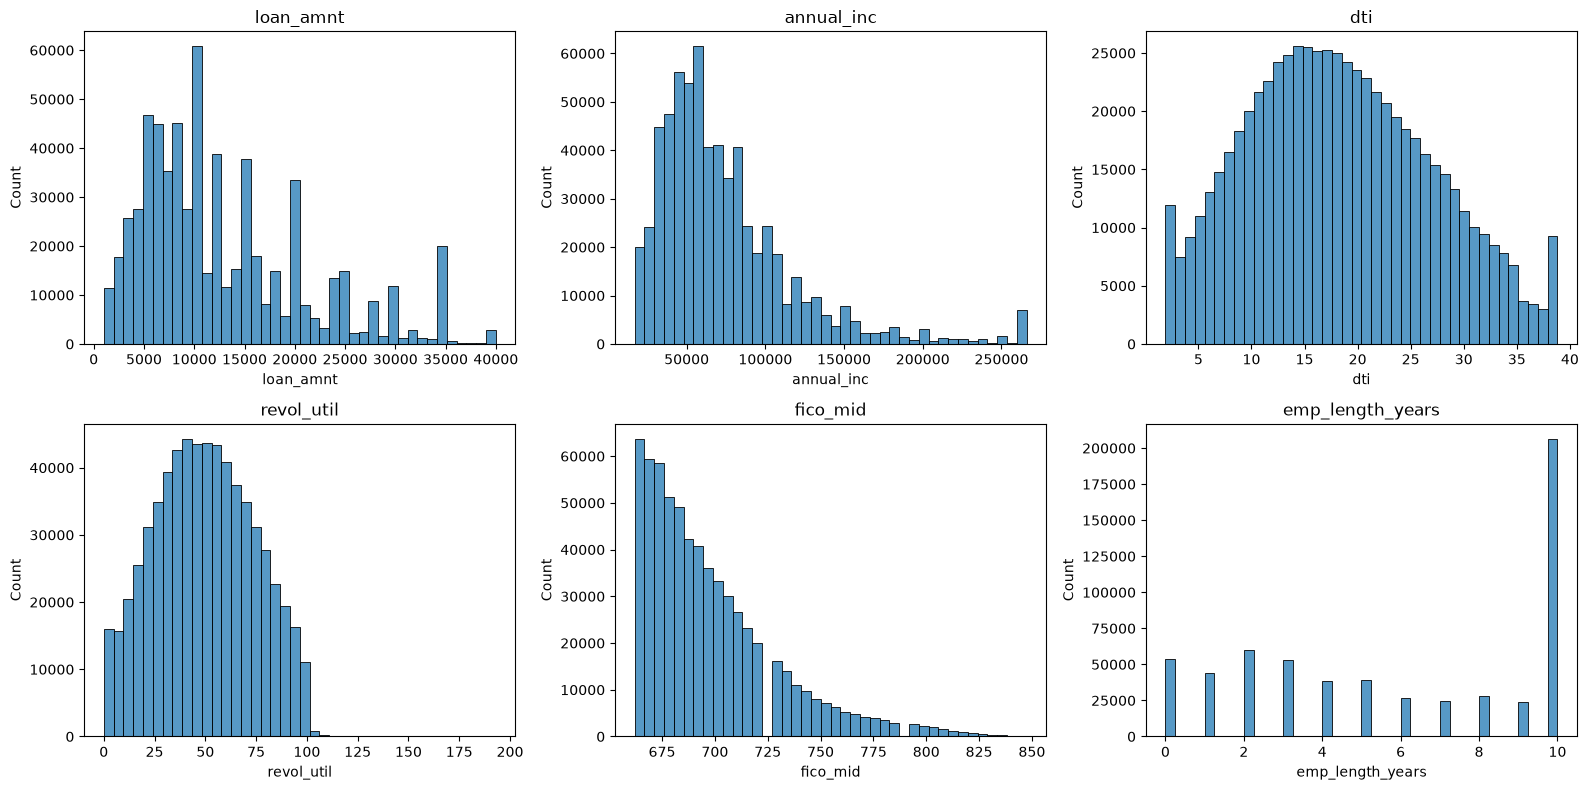

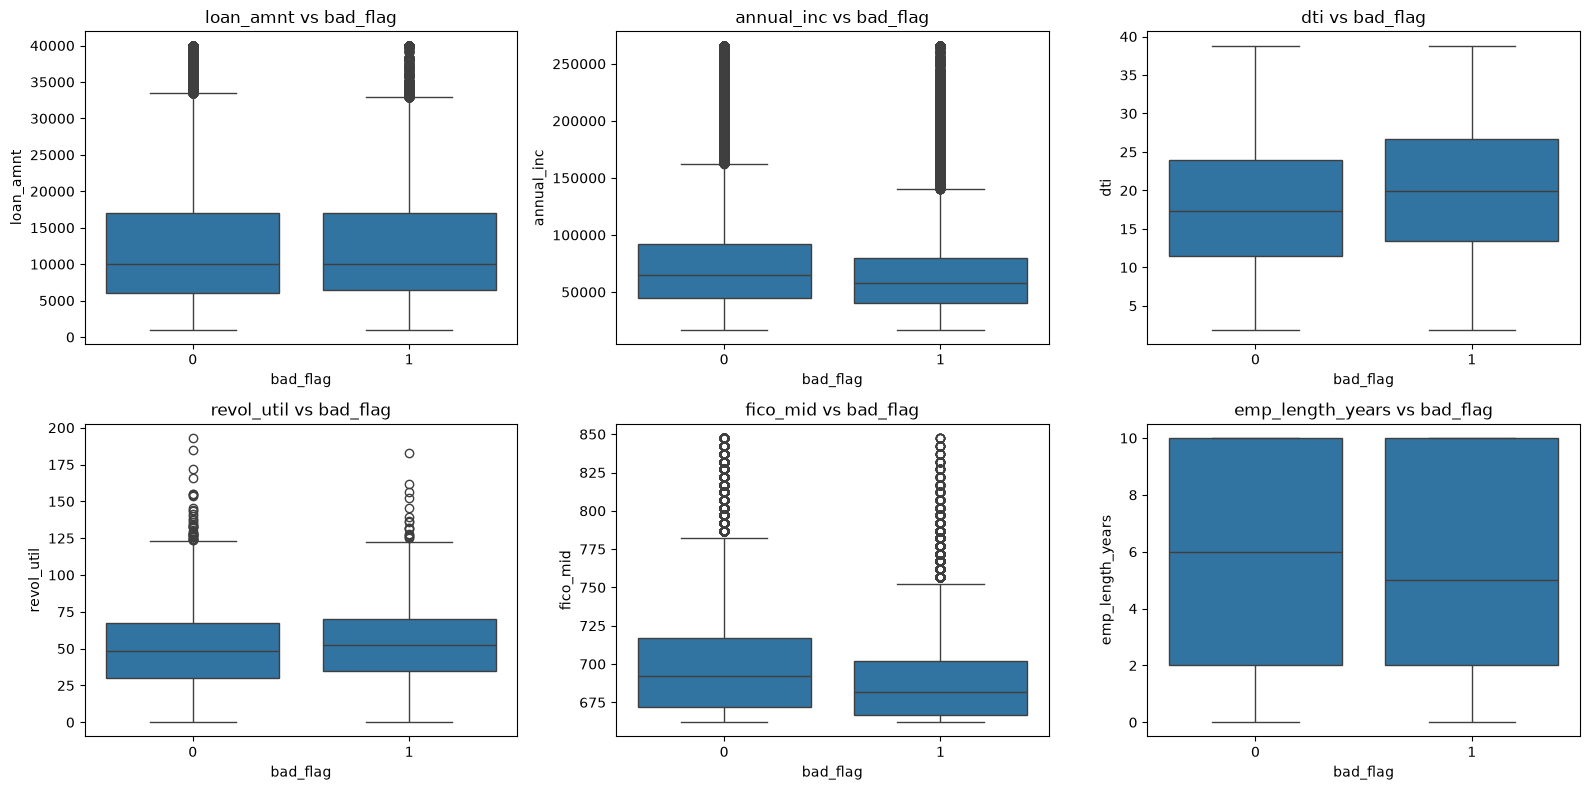

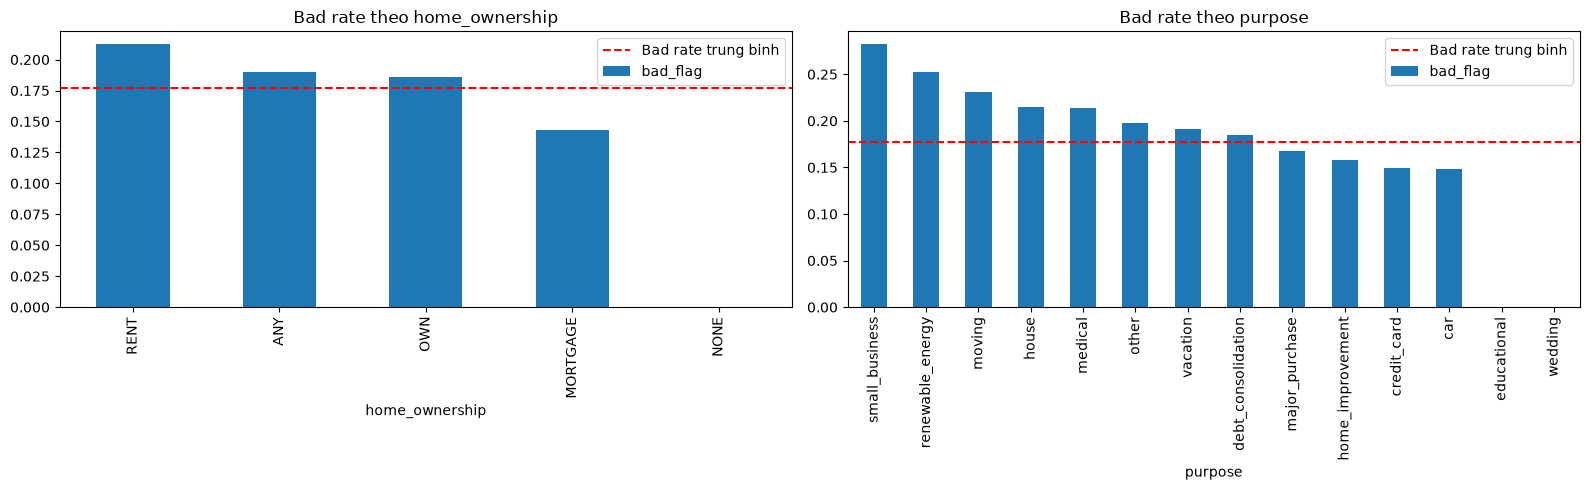

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

numeric_plot_cols = ['loan_amnt', 'annual_inc', 'dti', 'revol_util', 'fico_mid', 'emp_length_years']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_plot_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'univariate_numeric.png', dpi=100)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_plot_cols):
    sns.boxplot(data=df, x='bad_flag', y=col, ax=ax)
    ax.set_title(f'{col} vs bad_flag')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'bivariate_numeric_vs_bad.png', dpi=100)
plt.show()

cat_cols = ['home_ownership', 'purpose']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)['bad_flag'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax)
    ax.set_title(f'Bad rate theo {col}')
    ax.axhline(df['bad_flag'].mean(), color='red', linestyle='--', label='Bad rate trung binh')
    ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'bivariate_categorical_vs_bad.png', dpi=100)
plt.show()


## WOE / IV

In [5]:
from optbinning import BinningProcess

# ==> MUC DICH CUA BUOC NAY: xep hang yeu to rui ro (RQ1) tren toan bo tap vintage.
# KHONG dung ket qua o day de chon bien cho model.
#
# Ly do (rui ro R5 trong sprint_1_review.md): tinh IV tren toan bo vintage nghia la da dung
# ca nhan cua ky test. Ban dau buoc chon bien duoc dat o day va da gay hau qua that:
# revol_util co IV 0.025 tren toan bo tap nhung chi 0.0146 tren train - duoi nguong 0.02 -
# nen le ra khong duoc vao model; hau qua la he so sai dau (+0.228) o notebook 04.
# => Buoc CHON BIEN da duoc chuyen sang notebook 03, tinh IV chi tren tap train.
numeric_features = [c for c in CANDIDATE_FEATURES if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in CANDIDATE_FEATURES if c not in numeric_features]
print('numeric:', numeric_features)
print('categorical:', categorical_features)

binning_process = BinningProcess(
    variable_names=CANDIDATE_FEATURES,
    categorical_variables=categorical_features,
)
X = df[CANDIDATE_FEATURES]
y = df['bad_flag']
binning_process.fit(X, y)

iv_table = binning_process.summary().sort_values('iv', ascending=False).reset_index(drop=True)
iv_table


numeric: ['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'acc_now_delinq', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'delinq_amnt', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mo_sin_old_il_acct', 'mort_acc', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'mths_since_rcnt_il', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_coll_amt', 'tot_cur_bal', 'tot_hi_cred_lim', 'total_

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,fico_mid,numerical,OPTIMAL,True,13,0.147485,0.018014,0.200555,0.429942
1,bc_open_to_buy,numerical,OPTIMAL,True,12,0.076844,0.009495,0.145262,0.087115
2,tot_hi_cred_lim,numerical,OPTIMAL,True,14,0.073657,0.00915,0.150282,0.137842
3,avg_cur_bal,numerical,OPTIMAL,True,12,0.070269,0.00872,0.141703,0.137801
4,acc_open_past_24mths,numerical,OPTIMAL,True,10,0.067234,0.008353,0.146906,0.267574
...,...,...,...,...,...,...,...,...,...
76,chargeoff_within_12_mths,numerical,OPTIMAL,True,1,0.0,0.0,0,0.0
77,acc_now_delinq,numerical,OPTIMAL,True,1,0.0,0.0,0,0.0
78,disbursement_method,categorical,OPTIMAL,True,1,0.0,0.0,0,0.0
79,application_type,categorical,OPTIMAL,True,1,0.0,0.0,0,0.0


In [6]:
# Luu bang IV lam ket qua xep hang yeu to rui ro (RQ1) - dung cho bao cao va dashboard.
# KHONG sinh shortlist o day nua: xem giai thich o cell tren (rui ro R5).
suspect = iv_table.loc[iv_table['iv'] > 0.5, 'name'].tolist()
if suspect:
    print(f'CANH BAO - IV > 0.5, kiem tra lai co phai leakage khong: {suspect}')
else:
    print('Khong co bien nao IV > 0.5 -> khong co dau hieu leakage ro rang.')

IV_THRESHOLD = 0.02
print(f'\nSo bien vuot nguong IV > {IV_THRESHOLD} tren TOAN BO vintage (chi de tham khao, '
      f'khong phai shortlist chinh thuc): {(iv_table["iv"] > IV_THRESHOLD).sum()}/{len(iv_table)}')
print('-> Shortlist chinh thuc duoc tinh lai tren tap TRAIN o notebook 03.')

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)
iv_table.to_csv(REPORTS_FIGURES / 'iv_table.csv', index=False)
print('\nDa luu bang xep hang IV (toan bo vintage) vao reports/figures/iv_table.csv')


Khong co bien nao IV > 0.5 -> khong co dau hieu leakage ro rang.

So bien vuot nguong IV > 0.02 tren TOAN BO vintage (chi de tham khao, khong phai shortlist chinh thuc): 42/81
-> Shortlist chinh thuc duoc tinh lai tren tap TRAIN o notebook 03.

Da luu bang xep hang IV (toan bo vintage) vao reports/figures/iv_table.csv


## RQ5 - Approval rate (tham khảo): accepted vs. rejected

Reject Stats và Accepted Loans **không cùng schema** (`Risk_Score` xấp xỉ FICO vs. `fico_range_low/high`) —
xem PROPOSAL.md mục 4.3. Approval rate ước tính dưới đây chỉ mang tính xấp xỉ, không phải reject-inference
chuẩn xác.

In [7]:
rejected = pd.read_parquet(DATA_INTERIM / 'rejected_vintage_2015_2017.parquet')

n_accepted = len(accepted)
n_rejected = len(rejected)
approx_approval_rate = n_accepted / (n_accepted + n_rejected)
print(f'Accepted (vintage, truoc loc term/status): dung so goc truoc loc o notebook 01')
print(f'Rejected trong cung vintage window: {n_rejected:,}')
print(f'Approx approval rate = accepted / (accepted + rejected) = {approx_approval_rate:.2%}')
print('(Xap xi - accepted o day da bi loc them theo term=36 thang va loan_status, nen mau so')
print(' thuc te cua accepted truoc loc con lon hon -> approval rate thuc te se cao hon so tren.)')

fico_mid = (accepted['fico_range_low'] + accepted['fico_range_high']) / 2
comparison = pd.DataFrame({
    'accepted_fico_mid': fico_mid.describe(),
    'rejected_risk_score': rejected['Risk_Score'].describe(),
})
comparison


Accepted (vintage, truoc loc term/status): dung so goc truoc loc o notebook 01
Rejected trong cung vintage window: 14,701,826
Approx approval rate = accepted / (accepted + rejected) = 4.20%
(Xap xi - accepted o day da bi loc them theo term=36 thang va loan_status, nen mau so
 thuc te cua accepted truoc loc con lon hon -> approval rate thuc te se cao hon so tren.)


,accepted_fico_mid,rejected_risk_score
count,643917.000000,5.355072e+06
mean,697.374367,6.340825e+02
std,32.175950,6.479658e+01
min,662.000000,3.000000e+02
25%,672.000000,5.930000e+02
50%,687.000000,6.360000e+02
75%,712.000000,6.730000e+02
max,847.500000,9.900000e+02
